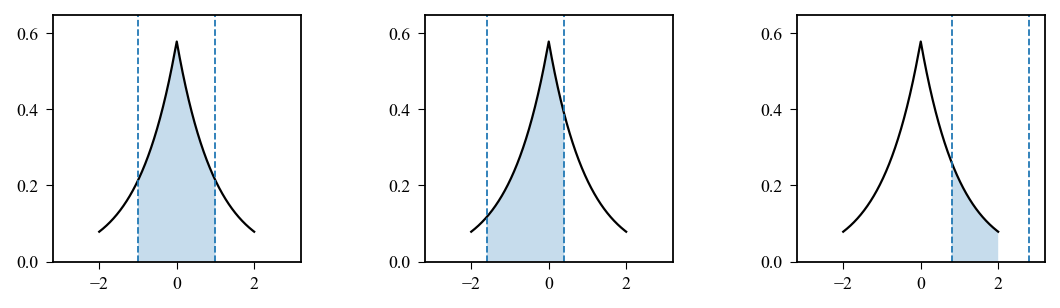

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# --- Times New Roman ---
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
})

# ---------- truncated Laplace (μ,b) on [a,c] ----------
def laplace_pdf(x, mu=0.0, b=1.0):
    return (1.0/(2.0*b)) * np.exp(-np.abs(x-mu)/b)

def laplace_cdf(x, mu=0.0, b=1.0):
    x = np.asarray(x)
    cdf = np.empty_like(x, dtype=float)
    left = x < mu
    cdf[left]  = 0.5 * np.exp((x[left]-mu)/b)
    cdf[~left] = 1.0 - 0.5 * np.exp(-(x[~left]-mu)/b)
    return cdf

def trunc_laplace_pdf(x, a, c, mu=0.0, b=1.0):
    Z = float(laplace_cdf(np.array([c]), mu, b) - laplace_cdf(np.array([a]), mu, b))
    y = laplace_pdf(x, mu, b) / Z
    y[(x < a) | (x > c)] = np.nan  # outside support -> don't draw
    return y

# ---------- 参数：初始设置 ----------
mu, b = 0.0, 1.0
a, c = -2.0, 2.0
d = 1.0                            # 虚线半宽
centers = [0.0, -0.6, c - 0.2]     # 三个中心
view_half_width = 3.2
fill_alpha = 0.25

# 要加在第二、第三个图顶上的公式
prob_expr = (
    r"$\mathbb{P}\left( \left|\left\langle \mathbf{q}_{j+1},"
    r" \mathbf{\Theta}\mathbf{z}_j + \mathbf{w}_{j} \right\rangle\right|"
    r"\leq k_0 \left\|\mathbf{q}_{j+1}\right\|_{2}"
    r"\,\mid\, \mathcal{F}_j \right)$"
)

fig, axes = plt.subplots(1, 3, figsize=(8, 2), dpi=160)

for idx, (ax, x0) in enumerate(zip(axes, centers)):
    L, R = x0 - d, x0 + d

    # x = np.linspace(x0 - view_half_width, x0 + view_half_width, 2000)
    x = np.linspace(0 - view_half_width, 0 + view_half_width, 2000)

    y = trunc_laplace_pdf(x, a, c, mu, b)

    # 曲线
    ax.plot(x, y, color='black', linewidth=1)

    # 填充：在虚线之间且在[a,c]内
    fill_left, fill_right = max(a, L), min(c, R)
    if fill_left < fill_right:
        xf = np.linspace(fill_left, fill_right, 800)
        yf = trunc_laplace_pdf(xf, a, c, mu, b)
        ax.fill_between(xf, 0.0, yf, alpha=fill_alpha)

    # 两条虚线（保持间距一致）
    ax.axvline(L, linestyle="--", linewidth=0.8)
    ax.axvline(R, linestyle="--", linewidth=0.8)

    # 轴数字
    ax.tick_params(labelsize=8, width=0.5, length=3)

    # # 去掉右上边框
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

    # ax.set_xlim(x0 - view_half_width, x0 + view_half_width)
    ax.set_xlim(0 - view_half_width, 0 + view_half_width)



    ax.set_ylim(0, np.nanmax(y) * 1.12)

    # # 标题：第一个图写“center at 0”，第二、第三个图写概率公式
    # if idx == 0:
    #     ax.set_title("center at 0", fontsize=10)
    # else:
    #     ax.set_title(prob_expr, fontsize=10)

# 增大子图之间的间距，让每个图稍微小一点
fig.subplots_adjust(wspace=0.5)
plt.savefig("truncated_logconcave_1_3.pdf", bbox_inches="tight", backend="pdf")

plt.show()
